In [2]:
import os
import numpy as np
import pandas as pd
import datetime as dt
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
def replace_timestamps_with_step_times(df):
    step_names = ["prefetch", "fasterq_dump", "star", "deseq2"]
    for step_name in step_names:
        start_times = (pd.to_datetime(df[f"{step_name}_start_time"]) - dt.datetime(1970, 1, 1)).dt.total_seconds()
        end_times = (pd.to_datetime(df[f"{step_name}_end_time"]) - dt.datetime(1970, 1, 1)).dt.total_seconds()
        df[f"{step_name}_[s]"] = end_times - start_times

    return df

def to_seconds_since_epoch(series):
    return (pd.to_datetime(series) - dt.datetime(1970, 1, 1)).dt.total_seconds()

In [4]:
df_md = pd.read_csv("data/metadata.csv", index_col=0)
df_md = df_md.drop(["execution_mode", "instance_type", "s3_path", "index_release", "nproc"], axis=1)
df_md = df_md[df_md["error_type"].isin([float("nan"), "Early stopping"])]

df_md["SRR_filesize_bytes"] = df_md["SRR_filesize_bytes"] / 1000 ** 3
df_md["fastq_filesize_bytes"] = df_md["fastq_filesize_bytes"] / 1000 ** 3
df_md["bam_filesize_bytes"] = df_md["bam_filesize_bytes"] / 1000 ** 3
df_md = df_md.rename({"SRR_filesize_bytes": "SRR_filesize_[GB]", "fastq_filesize_bytes": "fastq_filesize_[GB]", "bam_filesize_bytes": "bam_filesize_[GB]"}, axis=1)
df_md = replace_timestamps_with_step_times(df_md)
df_md['pipeline_start_timestamp'] = to_seconds_since_epoch(df_md['prefetch_start_time'])
df_md['pipeline_end_timestamp'] = to_seconds_since_epoch(df_md['deseq2_end_time'])
df_md['pipeline_end_timestamp'] = np.where(df_md['error_type'].isna(), df_md['pipeline_end_timestamp'], to_seconds_since_epoch(df_md['star_end_time']))

In [5]:
pipeline_exec_times = (df_md["prefetch_[s]"] + df_md["fasterq_dump_[s]"] + df_md["star_[s]"] + df_md["deseq2_[s]"])

In [6]:
avg_pipeline_exec_time = pipeline_exec_times.mean().round(2)
std_pipeline_exec_time = pipeline_exec_times.std().round(2)
print(avg_pipeline_exec_time, std_pipeline_exec_time, pipeline_exec_times.max())

482.45 498.06 4875.0


In [7]:
## LOAD METRIC DATA
metrics_folder = "data/metrics"
nfs_vm_id = "i-0f971b9375eb902cc"

vm_ids = os.listdir(metrics_folder)
vm_ids.remove(f"{nfs_vm_id}.csv")
print(len(vm_ids))

56


In [8]:
dfs = []

for filename in tqdm(vm_ids):
    if filename.endswith(".csv"):
        filepath = os.path.join(metrics_folder, filename)
        df = pd.read_csv(filepath, index_col=0)
        df['instance_id'] = filename.split(".")[0]
        dfs.append(df)

df_metrics = pd.concat(dfs, ignore_index=True)
df_metrics["Timestamp"] = (pd.to_datetime(df_metrics["Timestamp"]).astype("int64") / 10 ** 9).astype("int64")

first_timestamp = df_metrics["Timestamp"].min()
df_md['pipeline_start_timestamp'] = df_md['pipeline_start_timestamp'] - first_timestamp
df_md['pipeline_end_timestamp'] = df_md['pipeline_end_timestamp'] - first_timestamp
df_metrics["Timestamp"] = df_metrics["Timestamp"] - first_timestamp

100%|██████████| 56/56 [00:00<00:00, 66.02it/s]


In [9]:
instance_start = df_metrics.loc[df_metrics.groupby("instance_id")["Timestamp"].idxmin()]
instance_end = df_metrics.loc[df_metrics.groupby("instance_id")["Timestamp"].idxmax()]
instance_start["state"] = "start"
instance_end["state"] = "end"
df_instance_state = pd.concat([instance_start, instance_end]).sort_values("instance_id")

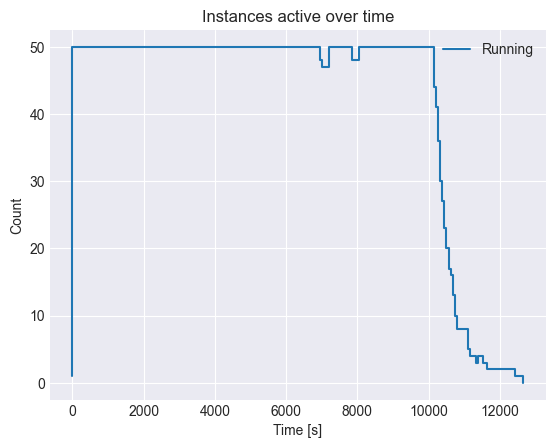

In [10]:
counts = []
times = []
count_active = 0

for index, row in df_instance_state.sort_values(by='Timestamp').iterrows():
    if row['state'] == 'start':
        count_active += 1
    else:
        count_active -= 1
    counts.append(count_active)
    times.append(row['Timestamp'])

df_running = pd.concat([pd.DataFrame(times, columns=["Timestamp"]), pd.DataFrame(counts, columns=["Running"])], axis=1)
df_running.plot.line(x="Timestamp", y="Running", xlabel="Time [s]", ylabel="Count", title="Instances active over time", drawstyle='steps-post');

In [11]:
def plot_df_state(df):
    df = df[["pipeline_start_timestamp", "pipeline_end_timestamp"]] - min(df_running["Timestamp"])

    df_sent = pd.DataFrame(df["pipeline_start_timestamp"])
    df_sent.columns = ["times"]
    df_sent["Active"] = 1
    df_sent["Completed"] = 0
    df_sent["Waiting"] = -1

    df_received = pd.DataFrame(df["pipeline_end_timestamp"])
    df_received.columns = ["times"]
    df_received["Active"] = -1
    df_received["Completed"] = 1
    df_received["Waiting"] = 0

    change_df = pd.concat([df_sent, df_received]).sort_values(by="times").reset_index(drop=True)
    active = change_df["Active"].cumsum()
    completed = change_df["Completed"].cumsum()
    waiting = max(completed) + change_df["Waiting"].cumsum()

    df_state = pd.DataFrame([active, completed, waiting]).T
    df_state["timestamp"] = change_df["times"]
    print("Max active: " + str(df_state["Active"].max()))

    fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

    df_state.plot.line(x="timestamp", ax=ax, drawstyle='steps-post', fontsize=18);
    plt.legend(fontsize=18)
    plt.xlabel("Time [s]", fontsize=23)
    plt.ylabel("Count", fontsize=23)
    plt.tight_layout()

    return df_state

Max active: 50


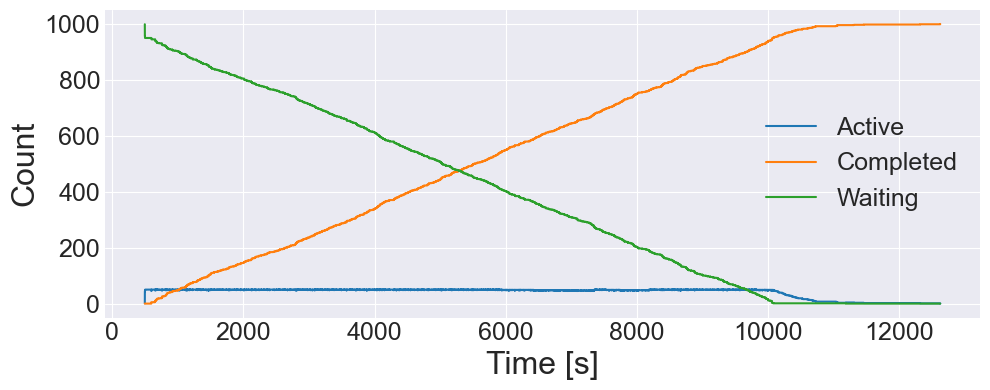

In [12]:
df_state = plot_df_state(df_md)
plt.savefig("plots/optimistic_spot_input_state.pdf", bbox_inches='tight')

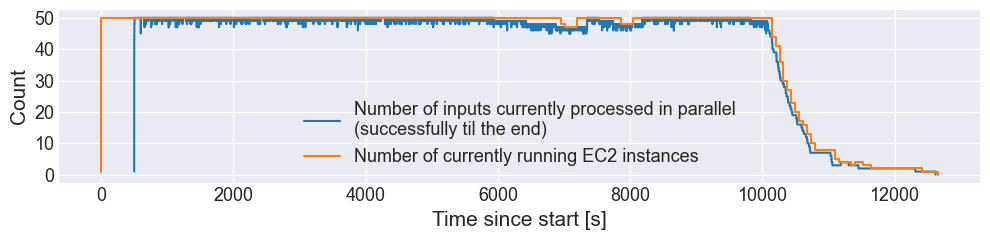

In [17]:
plt.figure(figsize=(10, 2.5))
df_state.plot.line(x="timestamp", ax=plt.gca(), y="Active", label="Number of inputs currently processed in parallel\n(successfully til the end)", xlabel="Time [s]", ylabel="Count", drawstyle='steps-post', fontsize=13)
df_running.plot.line(x="Timestamp", ax=plt.gca(), y="Running", label="Number of currently running EC2 instances", xlabel="Time [s]", ylabel="Count", drawstyle='steps-post', fontsize=13);

plt.xlabel("Time since start [s]", fontsize=15)
plt.ylabel("Count", fontsize=15)
plt.tight_layout()
plt.legend(fontsize=13, loc="lower center")
plt.savefig("plots/optimistic_spot_ec2_timeline.pdf", bbox_inches='tight')